In [1]:
import pandas as pd 
import numpy as np 
df = pd.read_csv('placement.csv')
df.sample(5)

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa
3,STU004,9.1,95.0,135.0,3.0,CSE,Placed,12.0
33,STU034,8.5,92.0,129.0,3.0,IT,Placed,9.7
59,STU060,8.2,88.0,120.0,2.0,ECE,Placed,7.3
49,STU050,6.2,63.0,85.0,0.0,ECE,Not Placed,0.0
40,STU041,7.4,75.0,104.0,1.0,ECE,Placed,5.1


/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/1417861140.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['package_lpa'])


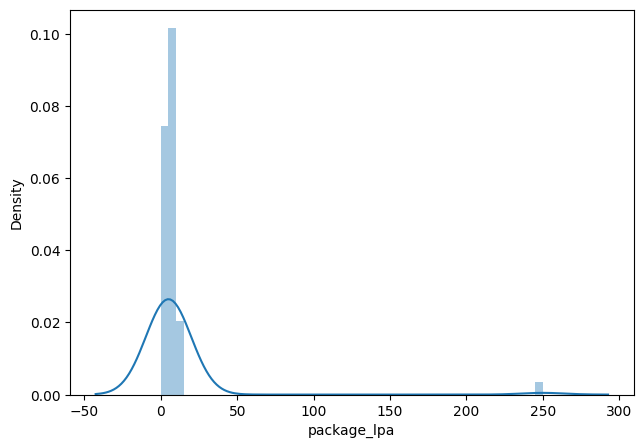

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16,5))
# plt.subplot(1,2,1)
# sns.distplot(df['cgpa'])
plt.subplot(1,2,1)
sns.distplot(df['package_lpa'])
plt.show()

In [4]:
df['package_lpa'].skew()

np.float64(7.488309025309027)

/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/2316600910.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


<Axes: xlabel='cgpa', ylabel='Density'>

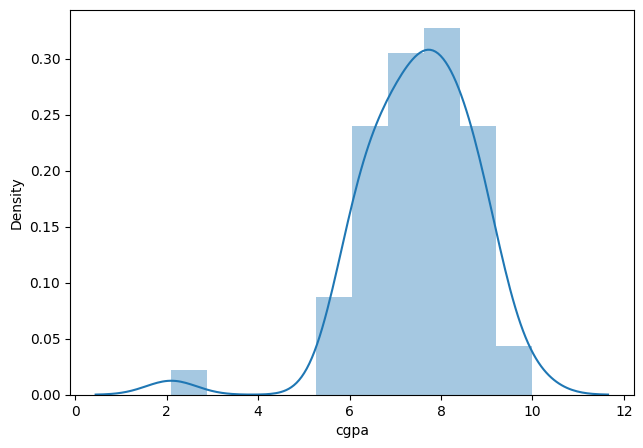

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

In [6]:
df['cgpa'].skew()

np.float64(-1.3022724993345642)

In [7]:

print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 7.510344827586207
Std value of cgpa 1.2416301756332084
Min value of cgpa 2.1
Max value of cgpa 10.0


In [8]:

# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 11.235235354485832
Lowest allowed 3.785454300686581


In [9]:
# Finding the outliers
df[(df['cgpa'] >11.23) | (df['cgpa'] < 3.78)]

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa
51,STU052,2.1,35.0,40.0,0.0,ME,Not Placed,0.0


In [10]:
# Trimming

new_df = df[(df['cgpa'] < 11.23) & (df['cgpa'] > 3.78)]
new_df

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa
0,STU001,8.6,92.0,128.0,2.0,CSE,Placed,8.5
1,STU002,7.4,78.0,105.0,1.0,IT,Placed,5.2
2,STU003,6.8,71.0,98.0,0.0,ECE,Not Placed,0.0
3,STU004,9.1,95.0,135.0,3.0,CSE,Placed,12.0
4,STU005,7.9,84.0,112.0,1.0,IT,Placed,6.4
5,STU006,6.2,65.0,89.0,0.0,ME,Not Placed,0.0
6,STU007,8.2,88.0,119.0,2.0,ECE,Placed,7.1
7,STU008,7.1,76.0,101.0,0.0,CSE,Not Placed,0.0
8,STU009,8.8,91.0,130.0,2.0,IT,Placed,9.3
9,STU010,6.9,73.0,95.0,1.0,CE,Not Placed,0.0


In [11]:
# Approach 2

# Calculating the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df.head()

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore
0,STU001,8.6,92.0,128.0,2.0,CSE,Placed,8.5,0.877600
1,STU002,7.4,78.0,105.0,1.0,IT,Placed,5.2,-0.088871
2,STU003,6.8,71.0,98.0,0.0,ECE,Not Placed,0.0,-0.572107
3,STU004,9.1,95.0,135.0,3.0,CSE,Placed,12.0,1.280297
4,STU005,7.9,84.0,112.0,1.0,IT,Placed,6.4,0.313825


In [12]:
df[df['cgpa_zscore'] > 3]


,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore


In [13]:
df[df['cgpa_zscore'] < -3]

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore
51,STU052,2.1,35.0,40.0,0.0,ME,Not Placed,0.0,-4.357453


In [14]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]


,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore
51,STU052,2.1,35.0,40.0,0.0,ME,Not Placed,0.0,-4.357453


In [15]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

new_df

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore
0,STU001,8.6,92.0,128.0,2.0,CSE,Placed,8.5,0.877600
1,STU002,7.4,78.0,105.0,1.0,IT,Placed,5.2,-0.088871
2,STU003,6.8,71.0,98.0,0.0,ECE,Not Placed,0.0,-0.572107
3,STU004,9.1,95.0,135.0,3.0,CSE,Placed,12.0,1.280297
4,STU005,7.9,84.0,112.0,1.0,IT,Placed,6.4,0.313825
5,STU006,6.2,65.0,89.0,0.0,ME,Not Placed,0.0,-1.055342
6,STU007,8.2,88.0,119.0,2.0,ECE,Placed,7.1,0.555443
7,STU008,7.1,76.0,101.0,0.0,CSE,Not Placed,0.0,-0.330489
8,STU009,8.8,91.0,130.0,2.0,IT,Placed,9.3,1.038679
9,STU010,6.9,73.0,95.0,1.0,CE,Not Placed,0.0,-0.491567


In [16]:
#CAPPING
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()
lower_limit
df['cgpa'] = np.where( df['cgpa']>upper_limit,upper_limit,
 np.where(df['cgpa']<lower_limit,lower_limit,df['cgpa']) )
df.shape

#np.where(x,y,z) x= condition y if true z if false

(60, 9)

In [17]:
df['cgpa'].describe()

count    58.000000
mean      7.539404
std       1.127237
min       3.785454
25%       6.800000
50%       7.600000
75%       8.375000
max      10.000000
Name: cgpa, dtype: float64

In [18]:
## usign iqr and box plot
## as seen above the package_lpa is skwed
df['package_lpa'].describe()

count     59.000000
mean       9.164407
std       32.157134
min        0.000000
25%        0.000000
50%        5.900000
75%        7.850000
max      250.000000
Name: package_lpa, dtype: float64

<Axes: ylabel='package_lpa'>

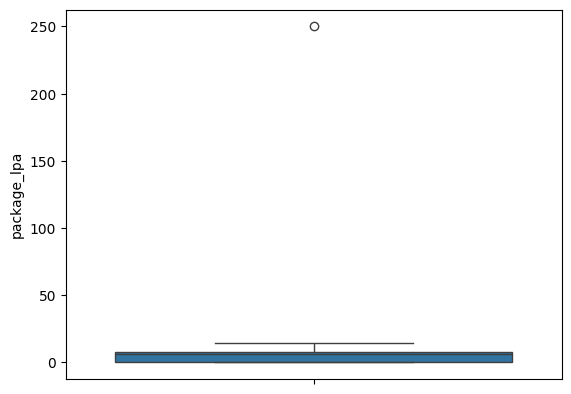

In [19]:
sns.boxplot(df['package_lpa'])

In [20]:
# Finding the IQR
percentile25 = df['package_lpa'].quantile(0.25)
percentile75 = df['package_lpa'].quantile(0.75)

In [21]:

iqr = percentile75 - percentile25

In [22]:
iqr

np.float64(7.85)

In [23]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr


In [24]:

print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 19.625
Lower limit -11.774999999999999


In [26]:
##finding outliers
df[df['package_lpa'] > upper_limit]

,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore
50,STU051,10.0,99.0,150.0,5.0,CSE,Placed,250.0,2.00515


In [27]:
df[df['package_lpa'] < lower_limit]


,student_id,cgpa,attendance,iq,internships,branch,placement,package_lpa,cgpa_zscore


In [28]:
# trimming
new_df = df[df['package_lpa'] < upper_limit]
new_df.shape

(58, 9)

/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/1845817366.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['package_lpa'])
/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/1845817366.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['package_lpa'

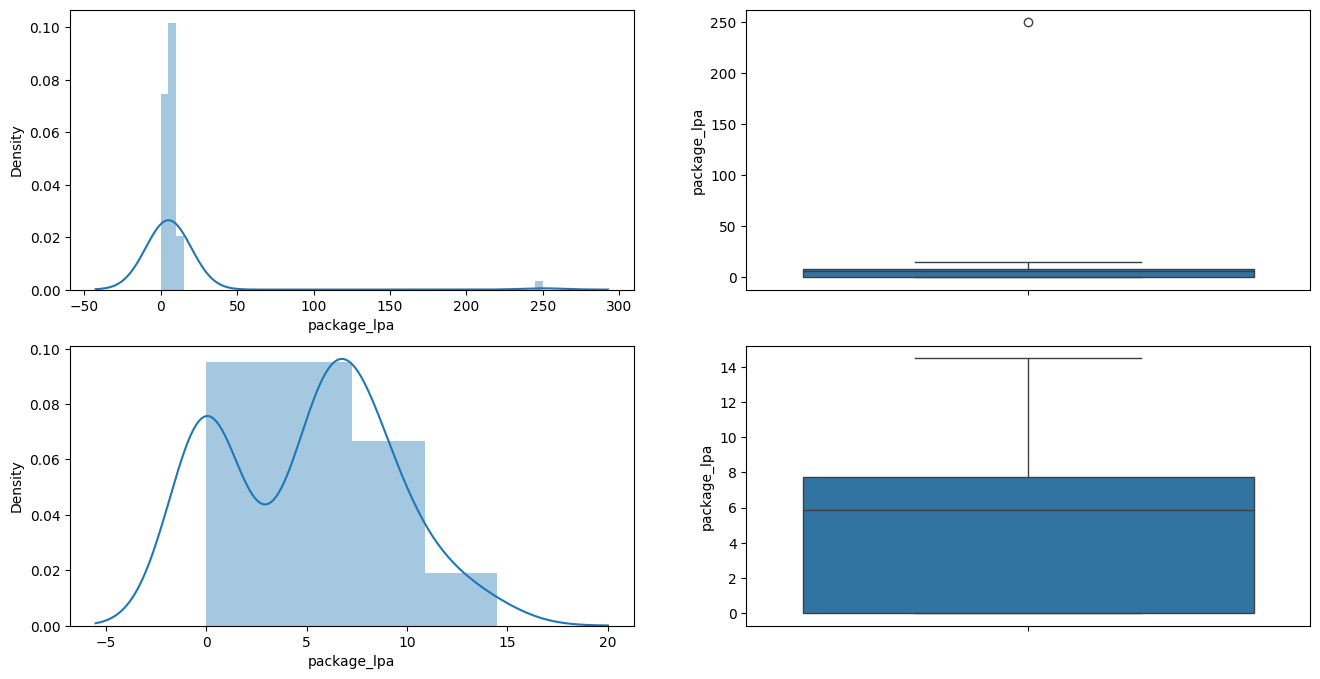

In [29]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['package_lpa'])

plt.subplot(2,2,2)
sns.boxplot(df['package_lpa'])

plt.subplot(2,2,3)
sns.distplot(new_df['package_lpa'])

plt.subplot(2,2,4)
sns.boxplot(new_df['package_lpa'])

plt.show()


In [30]:
#capping
new_df_cap = df.copy()

new_df_cap['package_lpa'] = np.where(
    new_df_cap['package_lpa'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['package_lpa'] < lower_limit,
        lower_limit,
        new_df_cap['package_lpa']
    )
)

/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/2803669664.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['package_lpa'])
/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/2803669664.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['package_

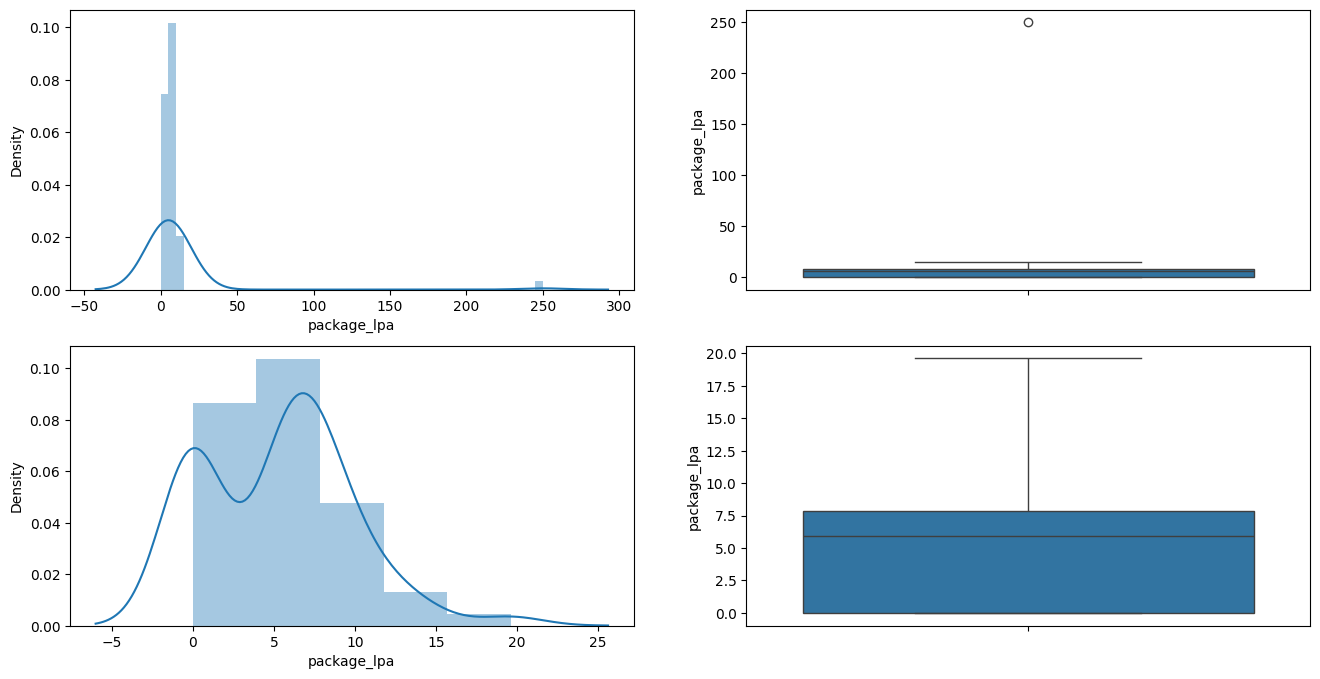

In [31]:

# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['package_lpa'])

plt.subplot(2,2,2)
sns.boxplot(df['package_lpa'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['package_lpa'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['package_lpa'])

plt.show()

/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/3628446644.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


<Axes: xlabel='cgpa', ylabel='Density'>

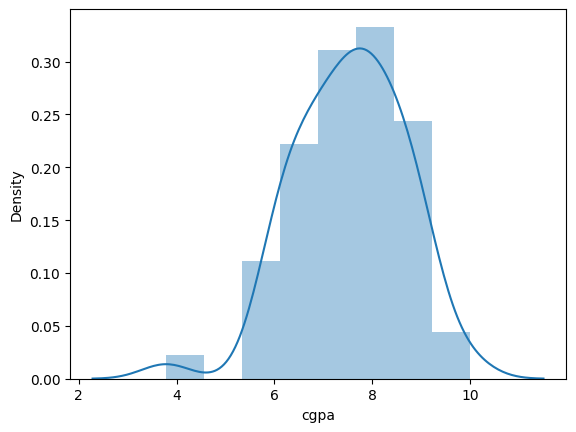

In [32]:
### USING PERCENTILE METHOD 

sns.distplot(df['cgpa'])

<Axes: ylabel='cgpa'>

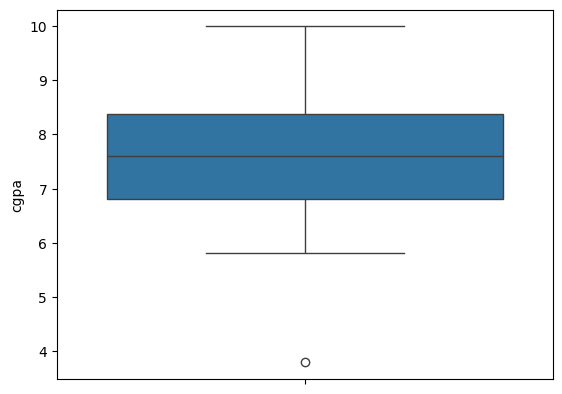

In [33]:
sns.boxplot(df['cgpa'])

In [35]:
upper_limit = df['cgpa'].quantile(0.99)
upper_limit
lower_limit = df['cgpa'].quantile(0.01)
lower_limit
new_df = df[(df['cgpa'] <= 74.78) & (df['cgpa'] >= 58.13)]
new_df['cgpa'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: cgpa, dtype: float64

In [36]:
df['cgpa'].describe()


count    58.000000
mean      7.539404
std       1.127237
min       3.785454
25%       6.800000
50%       7.600000
75%       8.375000
max      10.000000
Name: cgpa, dtype: float64

/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/2139853474.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['cgpa'])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/distributions.py:2464: RuntimeWarning: Mean of empty slice
  line, = ax.plot(a.mean(), 0)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: Runtim

<Axes: xlabel='cgpa'>

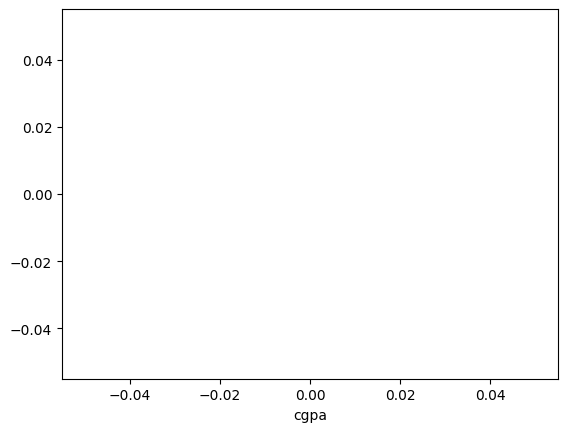

In [37]:
sns.distplot(new_df['cgpa'])


In [38]:
# Capping --> Winsorization
df['cgpa'] = np.where(df['cgpa'] >= upper_limit,
        upper_limit,
        np.where(df['cgpa'] <= lower_limit,
        lower_limit,
        df['cgpa']))

/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_49222/2044645673.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


<Axes: xlabel='cgpa', ylabel='Density'>

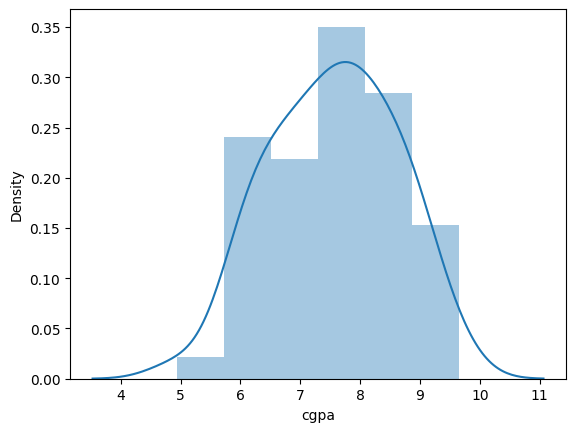

In [39]:

sns.distplot(df['cgpa'])


In [40]:
df['cgpa'].describe()


count    58.000000
mean      7.553306
std       1.055876
min       4.933745
25%       6.800000
50%       7.600000
75%       8.375000
max       9.658000
Name: cgpa, dtype: float64